# Assignment 4

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

### Loading the dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Shape of dataset: (50000, 2)

Column names:
Index(['review', 'sentiment'], dtype='object')

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


### Basic Text preprocessing

In [5]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [6]:
df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...,positive


In [7]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

df.head()

,review,sentiment,clean_review,label
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,1


### Train test split

In [8]:
X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


### Q1. Bag-of-Words vs TF-IDF

##### Bag-of-Words using CountVectorizer

In [9]:
bow_vectorizer = CountVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW training shape:", X_train_bow.shape)
print("BoW testing shape:", X_test_bow.shape)

BoW training shape: (40000, 10000)
BoW testing shape: (10000, 10000)


##### TF-IDF representation

In [10]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (40000, 10000)
TF-IDF testing shape: (10000, 10000)


Bag-of-Words represents text based on the frequency of words in a document, whereas TF-IDF assigns higher importance to words that are frequent in a particular document but less common across the entire dataset. For sentiment analysis, I expect TF-IDF to perform better because it reduces the importance of very common words and gives more weight to words that are more informative for distinguishing positive and negative reviews.

### Q2. Word Clouds

##### Positive reviews word cloud

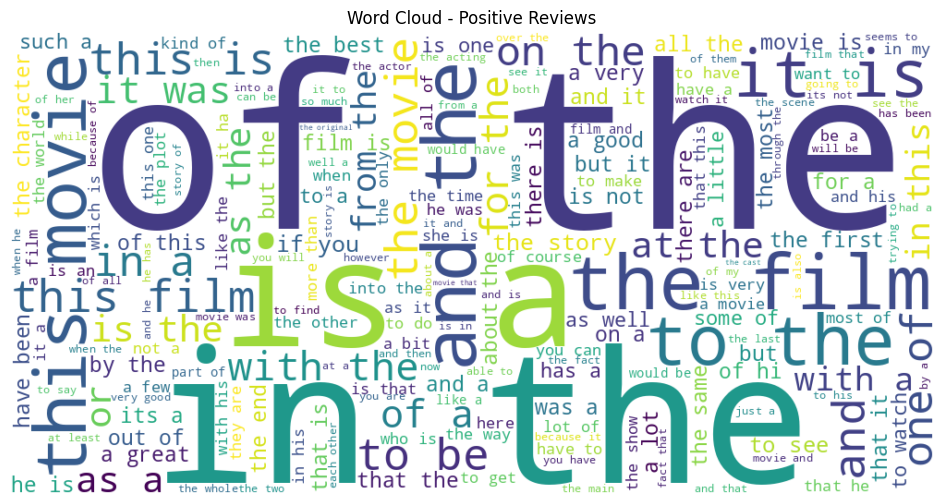

In [11]:
positive_reviews = " ".join(
    df[df["sentiment"] == "positive"]["clean_review"]
)

positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords="english"
).generate(positive_reviews)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

##### Negative reviews word cloud

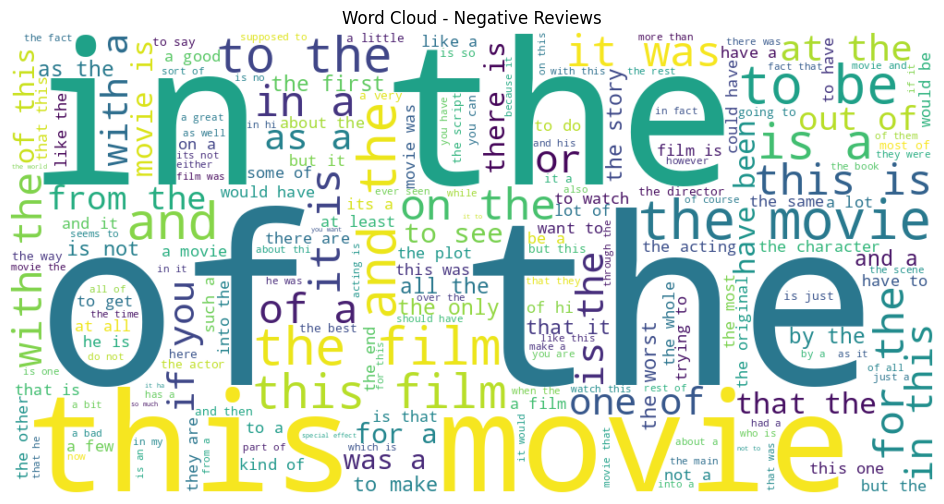

In [12]:
negative_reviews = " ".join(
    df[df["sentiment"] == "negative"]["clean_review"]
)

negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords="english"
).generate(negative_reviews)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

Observation: The positive review word cloud contains words that are generally associated with appreciation and quality, while the negative review word cloud contains words associated with criticism and dissatisfaction. Some common words may appear in both classes because they are related to movies in general rather than sentiment.

### Q3. Naive Bayes + Bag-of-Words

In [13]:
nb_bow = MultinomialNB()
start_time = time.time()
nb_bow.fit(X_train_bow, y_train)
nb_bow_time = time.time() - start_time

print("Training time:", round(nb_bow_time, 4), "seconds")

Training time: 0.0198 seconds


In [14]:
y_pred_nb_bow = nb_bow.predict(X_test_bow)

In [15]:
nb_bow_accuracy = accuracy_score(y_test, y_pred_nb_bow)
nb_bow_precision = precision_score(y_test, y_pred_nb_bow)
nb_bow_recall = recall_score(y_test, y_pred_nb_bow)
nb_bow_f1 = f1_score(y_test, y_pred_nb_bow)

print("Naive Bayes + BoW")
print("-----------------")
print("Accuracy :", round(nb_bow_accuracy, 4))
print("Precision:", round(nb_bow_precision, 4))
print("Recall   :", round(nb_bow_recall, 4))
print("F1-score :", round(nb_bow_f1, 4))

Naive Bayes + BoW
-----------------
Accuracy : 0.8471
Precision: 0.8554
Recall   : 0.8354
F1-score : 0.8453


### Q4. Naive Bayes + TF-IDF

In [16]:
nb_tfidf = MultinomialNB()
start_time = time.time()
nb_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf_time = time.time() - start_time

print("Training time:", round(nb_tfidf_time, 4), "seconds")

Training time: 0.0255 seconds


In [17]:
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

In [18]:
nb_tfidf_accuracy = accuracy_score(y_test, y_pred_nb_tfidf)
nb_tfidf_precision = precision_score(y_test, y_pred_nb_tfidf)
nb_tfidf_recall = recall_score(y_test, y_pred_nb_tfidf)
nb_tfidf_f1 = f1_score(y_test, y_pred_nb_tfidf)

print("Naive Bayes + TF-IDF")
print("--------------------")
print("Accuracy :", round(nb_tfidf_accuracy, 4))
print("Precision:", round(nb_tfidf_precision, 4))
print("Recall   :", round(nb_tfidf_recall, 4))
print("F1-score :", round(nb_tfidf_f1, 4))

Naive Bayes + TF-IDF
--------------------
Accuracy : 0.8554
Precision: 0.854
Recall   : 0.8574
F1-score : 0.8557


### Q5. Logistic Regression + TF-IDF

In [20]:
logistic_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)
start_time = time.time()
logistic_tfidf.fit(X_train_tfidf, y_train)
logistic_tfidf_time = time.time() - start_time

print("Training time:", round(logistic_tfidf_time, 4), "seconds")

Training time: 0.5596 seconds


In [21]:
y_pred_logistic = logistic_tfidf.predict(X_test_tfidf)

In [22]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression + TF-IDF")
print("----------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-score :", round(logistic_f1, 4))

Logistic Regression + TF-IDF
----------------------------
Accuracy : 0.8948
Precision: 0.8872
Recall   : 0.9046
F1-score : 0.8958


### Q6. Comparison Table

In [23]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes + BoW",
        "Naive Bayes + TF-IDF",
        "Logistic Regression + TF-IDF"
    ],
    "Accuracy": [
        nb_bow_accuracy,
        nb_tfidf_accuracy,
        logistic_accuracy
    ],
    "Precision": [
        nb_bow_precision,
        nb_tfidf_precision,
        logistic_precision
    ],
    "Recall": [
        nb_bow_recall,
        nb_tfidf_recall,
        logistic_recall
    ],
    "F1-score": [
        nb_bow_f1,
        nb_tfidf_f1,
        logistic_f1
    ],
    "Training Time (sec)": [
        nb_bow_time,
        nb_tfidf_time,
        logistic_tfidf_time
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,Training Time (sec)
0,Naive Bayes + BoW,0.8471,0.8554,0.8354,0.8453,0.0198
1,Naive Bayes + TF-IDF,0.8554,0.8540,0.8574,0.8557,0.0255
2,Logistic Regression + TF-IDF,0.8948,0.8872,0.9046,0.8958,0.5596


In [24]:
best_model = results.loc[
    results["F1-score"].idxmax()
]

print("Best model based on F1-score:")
print(best_model)

Best model based on F1-score:
Model                  Logistic Regression + TF-IDF
Accuracy                                     0.8948
Precision                                  0.887211
Recall                                       0.9046
F1-score                                   0.895821
Training Time (sec)                        0.559595
Name: 2, dtype: object


### Q7. Confusion Matrix

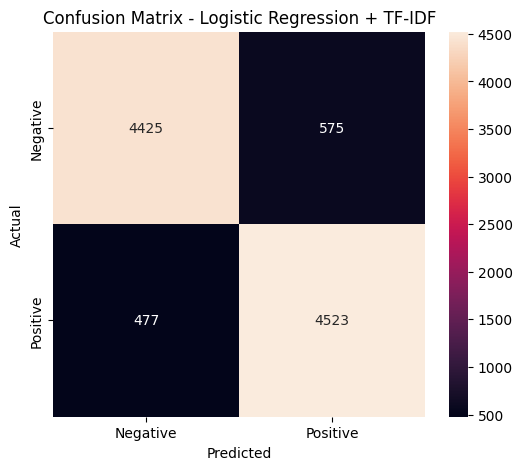

In [25]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression + TF-IDF")
plt.show()

### Q8. Which model performed better overall?

In [26]:
best_model_name = results.loc[
    results["F1-score"].idxmax(), "Model"
]

print("The model that performed best overall was:", best_model_name)

The model that performed best overall was: Logistic Regression + TF-IDF


Based on the comparison table, Logistic Regression + TF-IDF performed better overall because it achieved the highest F1-score and showed strong accuracy, precision and recall compared with the other approaches. F1-score is particularly useful here because it considers both precision and recall.

### Q9. Which model is more interpretable and why?

Logistic Regression is more interpretable because its learned coefficients indicate how strongly individual words contribute toward positive or negative sentiment. A positive coefficient indicates that a word pushes the prediction toward the positive class, while a negative coefficient pushes it toward the negative class.

In [27]:
feature_names = tfidf_vectorizer.get_feature_names_out()

coefficients = logistic_tfidf.coef_[0]

word_weights = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
})

positive_words = word_weights.sort_values(
    "weight", ascending=False
).head(10)

negative_words = word_weights.sort_values(
    "weight", ascending=True
).head(10)

print("Words strongly associated with positive sentiment:")
print(positive_words)

print("\nWords strongly associated with negative sentiment:")
print(negative_words)

Words strongly associated with positive sentiment:
           word    weight
3913      great  7.525403
3113  excellent  7.008065
6466    perfect  5.317079
815        best  5.217527
277     amazing  5.203116
9880  wonderful  4.798422
5329      loved  4.792372
4203  hilarious  4.556893
2987    enjoyed  4.505681
3325   favorite  4.502788

Words strongly associated with negative sentiment:
          word     weight
9912     worst -10.297368
9703     waste  -8.334931
619      awful  -8.029159
648        bad  -7.613429
973     boring  -6.421797
6673      poor  -5.770034
8966  terrible  -5.685259
9910     worse  -5.384162
2769      dull  -5.318720
6674    poorly  -5.271896


### Q10. Which model would you deploy?

I would deploy the model that provides the best balance between predictive performance and computational cost. If Logistic Regression + TF-IDF gives the highest F1-score with an acceptable training time, I would choose it for production. It also has the advantage of being relatively interpretable and efficient for sparse text data. However, if Naive Bayes provides similar performance with significantly lower training time, it could be preferred when simplicity and speed are more important.